# 03 — Temperature analysis

> **Synthetic demonstration.** These summaries show that the processed dataset
> is usable; they make no claim about San Ramón climate.

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display

ROOT = next(
    candidate
    for candidate in [Path.cwd(), *Path.cwd().parents]
    if (candidate / "src" / "weather_pipeline").exists()
)
sys.path.insert(0, str(ROOT / "src"))
SAMPLE = ROOT / "data" / "sample"
FIGURES = ROOT / "figures"
FIGURES.mkdir(exist_ok=True)
plt.style.use("seaborn-v0_8-whitegrid")


In [2]:
from weather_pipeline import (
    apply_quality_flags,
    concatenate_sources,
    load_campbell_csv,
    load_davis_30min_csv,
    load_davis_interval_extrema_csv,
)

campbell = load_campbell_csv(
    SAMPLE / "synthetic_campbell_hourly.csv",
    source="synthetic_campbell_hourly",
    instrument="Synthetic Campbell-like source",
)
davis = load_davis_30min_csv(
    SAMPLE / "synthetic_davis_30min.csv",
    source="synthetic_davis_30min",
    instrument="Synthetic Davis-like source",
)
extrema = load_davis_interval_extrema_csv(
    SAMPLE / "synthetic_davis_5min_extrema.csv",
    source="synthetic_davis_5min_interval_extrema",
    instrument="Synthetic Davis-like source",
)
observations = apply_quality_flags(
    concatenate_sources([campbell, davis, extrema])
)


In [3]:
from weather_pipeline import monthly_temperature_summary, resample_hourly

hourly = resample_hourly(
    observations,
    statistic="mean",
    minimum_coverage=0.5,
)
monthly = monthly_temperature_summary(observations)
display(monthly)

,source,instrument,month,observations,mean_c,median_c,q05_c,q95_c
0,synthetic_campbell_hourly,Synthetic Campbell-like source,2017-04-01,323,21.692910,21.680,18.1700,25.1690
1,synthetic_campbell_hourly,Synthetic Campbell-like source,2017-05-01,742,21.781078,21.825,18.1110,25.4595
2,synthetic_campbell_hourly,Synthetic Campbell-like source,2017-06-01,720,21.474556,21.410,17.9695,24.9415
3,synthetic_campbell_hourly,Synthetic Campbell-like source,2017-07-01,372,22.256559,22.300,18.9755,25.6845
4,synthetic_davis_30min,Synthetic Davis-like source,2017-04-01,643,20.441026,20.440,16.9310,23.9000
5,synthetic_davis_30min,Synthetic Davis-like source,2017-05-01,1486,20.538876,20.630,16.8600,24.1900
6,synthetic_davis_30min,Synthetic Davis-like source,2017-06-01,1440,20.224604,20.155,16.7100,23.7005
7,synthetic_davis_30min,Synthetic Davis-like source,2017-07-01,744,21.006048,21.060,17.7200,24.4400


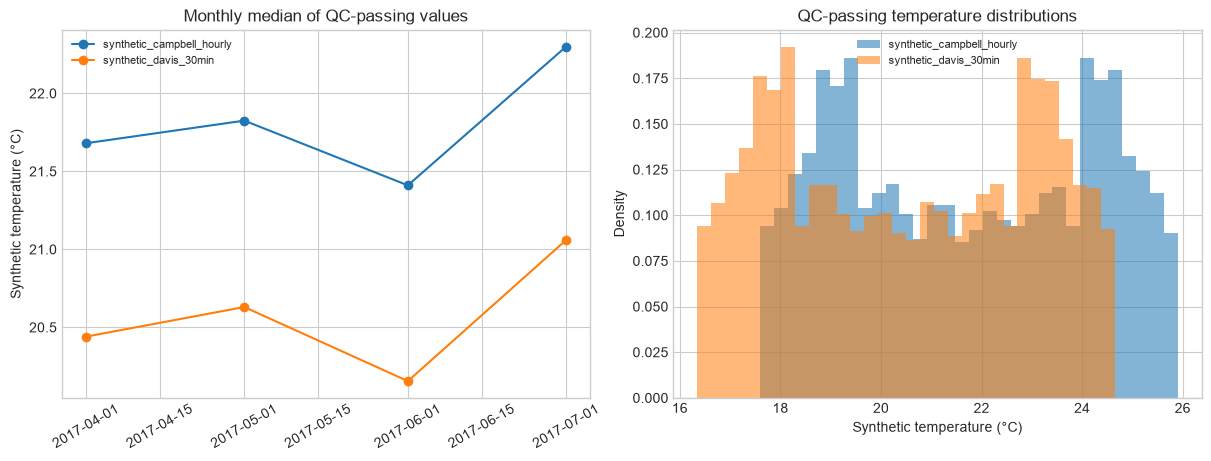

WindowsPath('figures/demo_temperature_analysis.png')

In [4]:
clean_air = observations.loc[
    observations["qc_pass"] & observations["measurement_type"].eq("air_temperature")
].copy()

fig, (monthly_axis, distribution_axis) = plt.subplots(
    1, 2, figsize=(12, 4.5), constrained_layout=True
)
for source, group in monthly.groupby("source"):
    monthly_axis.plot(group["month"], group["median_c"], marker="o", label=source)
monthly_axis.set_title("Monthly median of QC-passing values")
monthly_axis.set_ylabel("Synthetic temperature (°C)")
monthly_axis.tick_params(axis="x", rotation=30)
monthly_axis.legend(fontsize=8)

for source, group in clean_air.groupby("source"):
    distribution_axis.hist(
        group["temperature_clean_c"], bins=30, alpha=0.55, density=True, label=source
    )
distribution_axis.set_title("QC-passing temperature distributions")
distribution_axis.set_xlabel("Synthetic temperature (°C)")
distribution_axis.set_ylabel("Density")
distribution_axis.legend(fontsize=8)

output = FIGURES / "demo_temperature_analysis.png"
fig.savefig(output, dpi=160, bbox_inches="tight")
plt.show()
output.relative_to(ROOT)

In [5]:
hourly_summary = (
    hourly.groupby("source")
    .agg(
        hourly_rows=("timestamp", "size"),
        usable_hourly_values=("temperature_clean_c", "count"),
        median_coverage=("coverage_fraction", "median"),
    )
    .reset_index()
)
display(hourly_summary)

,source,hourly_rows,usable_hourly_values,median_coverage
0,synthetic_campbell_hourly,2160,2157,1.0
1,synthetic_davis_30min,2160,2158,1.0


The hourly table records how many native observations contributed
to each value and never combines instruments silently. Interval maximum/minimum
records are excluded because their temporal statistic is not equivalent to the
air-temperature observations.